In [1]:
import pandas as pd
import numpy as np
from typing import List, Tuple, Dict
from sklearn.cluster import HDBSCAN
import xgboost as xgb
from tqdm import tqdm
import joblib


class DateRangeScaler:
    def __init__(self):
        self.means = None
        self.stds = None
        self.fitted = False

    def fit(self, df: pd.DataFrame, feature_cols: List[str]):
        self.means = df[feature_cols].mean()
        self.stds = df[feature_cols].std().replace(0, 1)
        self.fitted = True

    def transform(self, df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
        if not self.fitted:
            raise ValueError("Scaler not fitted")

        df_scaled = df.copy()
        df_scaled[feature_cols] = (df[feature_cols] - self.means) / self.stds
        return df_scaled

    # def fit_transform(self, df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
    #     self.fit(df, feature_cols)
    #     return self.transform(df, feature_cols)


class DataManager:
    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: List[str],
        delay_cols: List[str] = ["1_w_delay", "1_m_delay", "target_return"],
        date_col: str = "TRADEDATE",
        id_col: str = "SECID",
        use_scaler: bool = False,
        horizon_days: int = 180,
    ):  
        self.df = df.copy()
        self.secid2id = {s: i for i, s in enumerate(sorted(self.df["SECID"].unique()))}
        self.id2secid = {i: s for s, i in self.secid2id.items()}
        self.df["SECID_raw"] = self.df["SECID"]
        self.df["SECID"] = self.df["SECID"].map(self.secid2id)
        self.feature_cols = feature_cols
        self.delay_cols = delay_cols
        self.date_col = date_col
        self.id_col = id_col
        self.horizon_days = horizon_days

        self.use_scaler = use_scaler
        self.scaler = DateRangeScaler() if use_scaler else None

        self.df[self.date_col] = pd.to_datetime(self.df[self.date_col])
        self.df = self.df.sort_values([self.date_col, self.id_col]).reset_index(drop=True)

        self.available_dates = sorted(self.df[self.date_col].unique())

    def fit_scaler(self, start_date: str, end_date: str):
        if not self.use_scaler:
            return

        mask = (self.df[self.date_col] >= start_date) & (self.df[self.date_col] <= end_date)
        df_slice = self.df.loc[mask]

        self.scaler.fit(df_slice, self.feature_cols)

    def apply_scaler(self):
        if not self.use_scaler:
            return

        self.df = self.scaler.transform(self.df, self.feature_cols)

    def _get_nearest_available_date(self, target_date: pd.Timestamp) -> pd.Timestamp:
        """
        Returns the nearest available date <= target_date
        """
        valid_dates = [d for d in self.available_dates if d <= target_date]
        if not valid_dates:
            return None
        return max(valid_dates)

    # def get_snapshot_with_lag(
    #     self,
    #     reference_date: str,
    #     lag_days: int,
    # ) -> pd.DataFrame:
    #     """
    #     Returns data for reference_date minus lag_days using nearest available date,
    #     accounting for horizon to avoid lookahead bias
    #     """
    #     reference_date = pd.to_datetime(reference_date)
    #     target_date = reference_date - pd.Timedelta(days=lag_days)

    #     nearest_date = self._get_nearest_available_date(target_date)
    #     if nearest_date is None:
    #         return pd.DataFrame()

    #     max_date = self.df[self.date_col].max()
    #     cutoff_date = max_date - pd.Timedelta(days=self.horizon_days)

    #     if nearest_date > cutoff_date:
    #         return pd.DataFrame()

    #     df_slice = self.df[self.df[self.date_col] == nearest_date]

    #     cols = [self.id_col, self.date_col] + self.feature_cols + self.delay_cols
    #     return df_slice[cols].dropna()

    # def get_multi_horizon_snapshots(
    #     self,
    #     reference_date: str,
    #     lags: List[int] = [14, 42, 182],
    # ) -> Dict[int, pd.DataFrame]:
    #     """
    #     Returns data snapshots for multiple lag horizons
    #     """
    #     result = {}

    #     for lag in lags:
    #         result[lag] = self.get_snapshot_with_lag(reference_date, lag)

    #     return result

    def get_training_data(
        self,
        start_date: str,
        end_date: str,
        target_col: str,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Returns training data filtered by date range and horizon cutoff
        """
        max_date = self.df[self.date_col].max()
        cutoff_date = max_date - pd.Timedelta(days=self.horizon_days)

        mask = (
            (self.df[self.date_col] >= start_date) &
            (self.df[self.date_col] <= end_date) &
            (self.df[self.date_col] <= cutoff_date)
        )

        df_slice = self.df.loc[mask]
        df_slice = df_slice.dropna(subset=self.feature_cols + [target_col])

        X = df_slice[self.feature_cols].values
        y = df_slice[target_col].values

        return X, y

    # def get_available_dates(self) -> List[pd.Timestamp]:
    #     return self.available_dates

    def get_features_by_date(self, date: str) -> pd.DataFrame:
        date = pd.to_datetime(date)
        return self.df[self.df[self.date_col] == date][
            [self.id_col] + self.feature_cols
        ].copy()

    # def decode_secid(self, secid_encoded):
    #     return self.id2secid.get(secid_encoded, secid_encoded)


class XGBModelWrapper:
    def __init__(self):
        self.model = xgb.XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42,
        )

    def fit(self, X, y):
        if len(X) == 0:
            return
        self.model.fit(X, y)

    def predict(self, X):
        if len(X) == 0:
            return np.array([])
        return self.model.predict(X)


class EnsembleOrchestrator:
    def __init__(
        self,
        data_manager,
        start_train_date: str,
        start_test_date: str,
        end_date: str,
        train_window_days: int = 365 * 3,
        step_days: int = 14,
        horizons: List[int] = [14, 42, 182],
    ):
        self.dm = data_manager

        self.start_train_date = pd.to_datetime(start_train_date)
        self.start_test_date = pd.to_datetime(start_test_date)
        self.end_date = pd.to_datetime(end_date)

        self.train_window_days = train_window_days
        self.step_days = step_days
        self.horizons = horizons

        self.models = {h: XGBModelWrapper() for h in horizons}

        self.pred_registry = []
        self.errors = {h: [] for h in horizons}

    def _compute_weights(self):
        """
        Compute ensemble weights based on historical prediction errors
        """
        weights = {}
        for h in self.horizons:
            errs = self.errors[h]
            if len(errs) == 0:
                weights[h] = 1.0
            else:
                weights[h] = 1.0 / (np.mean(errs) + 1e-6)

        s = sum(weights.values())
        return {k: v / s for k, v in weights.items()}

    def _train_models(self, current_date: pd.Timestamp):
        """
        Train models for all horizons using expanding window
        """
        train_start = current_date - pd.Timedelta(days=self.train_window_days)

        for h in self.horizons:
            target_col = f"target_return_{h}d"

            X, y = self.dm.get_training_data(
                start_date=str(train_start.date()),
                end_date=str(current_date.date()),
                target_col=target_col,
            )

            self.models[h].fit(X, y)

    def predict(self, df_day: pd.DataFrame):
        """
        Generate ensemble prediction using weighted average of individual models
        """
        if df_day.empty:
            return np.array([]), {}

        X = df_day[self.dm.feature_cols].values

        preds_by_model = {
            h: self.models[h].predict(X)
            for h in self.horizons
        }

        weights = self._compute_weights()

        ensemble_pred = np.zeros(len(X))
        for h in self.horizons:
            ensemble_pred += weights[h] * preds_by_model[h]

        return ensemble_pred, preds_by_model

    def _update_errors(self, current_date: pd.Timestamp):
        """
        Update prediction errors using delayed feedback mechanism
        """
        for record in self.pred_registry:
            pred_date = record["date"]

            df_true_full = self.dm.df[self.dm.df[self.dm.date_col] == current_date]

            if df_true_full.empty:
                continue

            ids_pred = record["ids"]
            preds_by_h = record["preds_by_h"]

            for h in self.horizons:
                if (current_date - pred_date).days < h:
                    continue

                target_col = f"target_return_{h}d"

                df_true = df_true_full[["SECID", target_col]].dropna()
                if df_true.empty:
                    continue

                true_map = dict(zip(df_true["SECID"], df_true[target_col]))

                aligned_true = np.array([true_map.get(secid, np.nan) for secid in ids_pred])
                mask = ~np.isnan(aligned_true)

                if mask.sum() == 0:
                    continue

                y_pred = np.asarray(preds_by_h[h])

                if len(y_pred) != len(ids_pred):
                    continue

                err = np.mean(np.abs(aligned_true[mask] - y_pred[mask]))
                self.errors[h].append(err)

    # def run(self):
    #     """
    #     Execute main training and prediction loop
    #     """
    #     current_date = self.start_test_date

    #     while current_date <= self.end_date:
    #         print(f"\n[{current_date.date()}]")

    #         self._train_models(current_date)
    #         self._predict(current_date)
    #         self._update_errors(current_date)

    #         weights = self._compute_weights()
    #         print("weights:", weights)
    #         print("errors:", {k: np.mean(v) if v else None for k, v in self.errors.items()})

    #         current_date += pd.Timedelta(days=self.step_days)


def portfolio_pipeline(
    df_day: pd.DataFrame,
    model,
    feature_cols,
    data_manager,
    secid_col="SECID",
    top_k_small=2,
    top_k_large=3,
):
    """
    Construct portfolio from daily predictions using clustering and top selection
    """
    df = df_day.copy()

    print("rows before filter:", len(df))
    print("rows after filter:", len(df[df["pred"] > 0]))
    df = df[df["pred"] > 0]

    if df.empty:
        return pd.DataFrame()

    clusterer = HDBSCAN(
        min_cluster_size=3,
        min_samples=3,
        metric="euclidean",
        cluster_selection_method="eom"
    )
    numeric_features = df[feature_cols].columns.tolist()
    df["cluster"] = clusterer.fit_predict(df[numeric_features].values)
    if df.empty:
        return pd.DataFrame()

    selected = []
    print("clusters:", np.unique(df["cluster"], return_counts=True))
    for c in df["cluster"].unique():
        cluster_df = df[df["cluster"] == c]
        cluster_df = cluster_df.sort_values("pred", ascending=False)

        k = top_k_large if len(cluster_df) > 5 else top_k_small
        selected.append(cluster_df.head(k))

    selected = pd.concat(selected)

    total = selected["pred"].sum()

    if total == 0:
        selected["weight"] = 1 / len(selected)
    else:
        selected["weight"] = selected["pred"] / total

    selected = selected.copy()
    selected["SECID"] = selected["SECID"].apply(data_manager.id2secid.get)

    return selected[["SECID", "pred", "weight", "cluster"]]


def evaluate_portfolio(portfolio, date, data_manager):
    """
    Calculate realized portfolio return at the horizon date
    """
    horizon = data_manager.horizon_days
    future_date = pd.to_datetime(date) + pd.Timedelta(days=horizon)

    future_date = data_manager._get_nearest_available_date(future_date)

    if future_date is None:
        print("No future data")
        return None

    target_col = f"target_return_{data_manager.horizon_days}d"

    df_future = data_manager.df[
        data_manager.df[data_manager.date_col] == future_date
    ][["SECID", target_col]].copy()

    df_future = df_future.rename(columns={target_col: "target_return"})

    df_future["SECID"] = df_future["SECID"].map(data_manager.id2secid)

    merged = portfolio.merge(df_future, on="SECID", how="left")

    merged = merged.dropna(subset=["target_return"])

    if merged.empty:
        print("No matched future returns")
        return None

    portfolio_return = (merged["weight"] * merged["target_return"]).sum()

    return portfolio_return, merged


def run_backtest(
    feature_cols,
    data_manager,
    start_train_date,
    start_test_date,
    end_date,
    portfolio_pipeline_fn,
    save_path="ensemble_180_1.pkl",
    step_days=14,
    portfolio_dates=None,
):
    """
    Execute full backtest: training loop followed by portfolio construction and evaluation
    """
    orchestrator = EnsembleOrchestrator(
        data_manager=data_manager,
        start_train_date=start_train_date,
        start_test_date=start_test_date,
        end_date=end_date,
        horizons=[14, 42, 182],
        step_days=step_days,
    )

    dates = pd.date_range(start_train_date, end_date, freq=f"{step_days}D")

    for current_date in tqdm(dates, desc="Training"):
        print(f"\nTRAIN DATE: {current_date.date()}")

        orchestrator._train_models(current_date)

        df_day = data_manager.get_features_by_date(current_date)
        if not df_day.empty:
            ensemble_pred, preds_by_model = orchestrator.predict(df_day)

            orchestrator.pred_registry.append({
                "date": current_date,
                "ids": df_day["SECID"].values,
                "preds_by_h": {
                    h: preds_by_model[h].copy()
                    for h in orchestrator.horizons
                }
            })

        orchestrator._update_errors(current_date)

    joblib.dump(orchestrator, save_path)
    print(f"\nMODEL SAVED -> {save_path}")
    last_errors = {h: errs[-1] if errs else None for h, errs in orchestrator.errors.items()}
    print(f"Last Errors:")
    for h, err in last_errors.items():
        print(f"  Horizon {h}: {err}")

    portfolios = []

    if portfolio_dates is not None:
        print("\n=== PORTFOLIO TEST ===")

        for d in tqdm(portfolio_dates, desc="Portfolio"):
            d = pd.to_datetime(d)
            print(f"\nPORTFOLIO DATE: {d.date()}")

            df_day = data_manager.get_features_by_date(d)

            if df_day.empty:
                print("No data for this date.")
                continue

            ensemble_pred, _ = orchestrator.predict(df_day)

            df_day = df_day.copy()
            df_day["pred"] = ensemble_pred

            portfolio = portfolio_pipeline_fn(
                df_day=df_day,
                model=None,
                feature_cols=feature_cols,
                data_manager=data_manager,
            )
            print(f"Selected {len(portfolio)} stocks for portfolio.")

            if not portfolio.empty:
                portfolios.append({
                    "date": d,
                    "portfolio": portfolio
                })

                print(portfolio.head())
                result = evaluate_portfolio(portfolio, d, data_manager)

                if result is not None:
                    port_ret, details = result

                    print(portfolio.head())
                    print("\nPortfolio return:", round(port_ret, 4))
                    print("Details:")
                    print(details.head())

                    print(portfolios)


if __name__ == "__main__":
    df = pd.read_csv('final_dataset (2).csv', parse_dates=['TRADEDATE'])

    feature_cols = [
        "momentum_6m", "momentum_12m", "momentum_24m", "momentum_36m",
        "volatility_6m", "volatility_12m", "volatility_24m", "volatility_36m",
        "max_drawdown_6m", "max_drawdown_12m", "max_drawdown_24m", "max_drawdown_36m",
        "avg_value_6m", "avg_value_12m", "avg_value_36m",
        "dividend_yield_12m", "dividend_yield_3y_avg", "dividend_consistency_3y",
        "relative_strength_12m", "excess_return_6m", "beta_12m",
        "log_issuesize", "cbr_key_rate"
    ]

    dm = DataManager(
        df=df,
        feature_cols=feature_cols,
        delay_cols=[
            "target_return_182d",
            "target_return_42d",
            "target_return_14d"
        ],
        date_col="TRADEDATE",
        id_col="SECID",
        use_scaler=True,
        horizon_days=182,
    )

    dm.fit_scaler(start_date="2015-01-01", end_date="2018-01-01")
    dm.apply_scaler()

    history = run_backtest(
        feature_cols=feature_cols,
        data_manager=dm,
        start_train_date="2015-01-01",
        start_test_date="2018-01-01",
        end_date="2024-01-01",
        portfolio_pipeline_fn=portfolio_pipeline,
        portfolio_dates=[
            "2024-08-05",
            "2024-09-03",
            "2025-04-03",
            "2025-05-05",
            "2025-06-06"
        ]
    )

Training:   5%|▌         | 12/235 [00:00<00:03, 59.30it/s]


TRAIN DATE: 2015-01-01

TRAIN DATE: 2015-01-15

TRAIN DATE: 2015-01-29

TRAIN DATE: 2015-02-12

TRAIN DATE: 2015-02-26

TRAIN DATE: 2015-03-12

TRAIN DATE: 2015-03-26

TRAIN DATE: 2015-04-09

TRAIN DATE: 2015-04-23

TRAIN DATE: 2015-05-07

TRAIN DATE: 2015-05-21

TRAIN DATE: 2015-06-04


Training:   8%|▊         | 19/235 [00:00<00:03, 62.31it/s]


TRAIN DATE: 2015-06-18

TRAIN DATE: 2015-07-02

TRAIN DATE: 2015-07-16

TRAIN DATE: 2015-07-30

TRAIN DATE: 2015-08-13

TRAIN DATE: 2015-08-27

TRAIN DATE: 2015-09-10

TRAIN DATE: 2015-09-24

TRAIN DATE: 2015-10-08

TRAIN DATE: 2015-10-22

TRAIN DATE: 2015-11-05

TRAIN DATE: 2015-11-19

TRAIN DATE: 2015-12-03


Training:  11%|█         | 26/235 [00:00<00:03, 58.42it/s]

...


MODEL SAVED -> ensemble_180_1.pkl
Last Errors:
  Horizon 14: 0.06704513480861686
  Horizon 42: 0.27167330940545026
  Horizon 182: 0.5734292547925732

=== PORTFOLIO TEST ===


Portfolio:  20%|██        | 1/5 [00:00<00:00,  8.94it/s]


PORTFOLIO DATE: 2024-08-05
rows before filter: 199
rows after filter: 123
clusters: (array([-1,  0,  1]), array([34, 85,  4]))
Selected 8 stocks for portfolio.
        SECID      pred    weight  cluster
293411   GMKN  0.534573  0.417129       -1
293543  TRNFP  0.252397  0.196946       -1
293511   RTSB  0.099518  0.077654       -1
293458  MISBP  0.086153  0.067226        0
293457   MISB  0.085681  0.066857        0
        SECID      pred    weight  cluster
293411   GMKN  0.534573  0.417129       -1
293543  TRNFP  0.252397  0.196946       -1
293511   RTSB  0.099518  0.077654       -1
293458  MISBP  0.086153  0.067226        0
293457   MISB  0.085681  0.066857        0

Portfolio return: 0.0008
Details:
   SECID      pred    weight  cluster  target_return
0   GMKN  0.534573  0.417129       -1       0.020118
1  TRNFP  0.252397  0.196946       -1       0.315604
2   RTSB  0.099518  0.077654       -1      -0.264151
3  MISBP  0.086153  0.067226        0      -0.118276
4   MISB  0.085681  0.0

Portfolio: 100%|██████████| 5/5 [00:00<00:00, 14.75it/s]

        SECID      pred    weight  cluster
326955  TRNFP  0.352582  0.208122       -1
326825   GMKN  0.215786  0.127373       -1
326981   YRSB  0.121512  0.071726       -1
326944  TASBP  0.153386  0.090541        4
326898   NNSB  0.142174  0.083922        4

Portfolio return: 0.1559
Details:
   SECID      pred    weight  cluster  target_return
0  TRNFP  0.352582  0.208122       -1       0.157784
1   GMKN  0.215786  0.127373       -1       0.325041
2   YRSB  0.121512  0.071726       -1       0.026570
3  TASBP  0.153386  0.090541        4       0.175166
4   NNSB  0.142174  0.083922        4       0.074442
[{'date': Timestamp('2024-08-05 00:00:00'), 'portfolio':         SECID      pred    weight  cluster
293411   GMKN  0.534573  0.417129       -1
293543  TRNFP  0.252397  0.196946       -1
293511   RTSB  0.099518  0.077654       -1
293458  MISBP  0.086153  0.067226        0
293457   MISB  0.085681  0.066857        0
293424   KCHE  0.074689  0.058280        0
293572   ZVEZ  0.078224  0.0610

Loading model from ensemble_180_1.pkl...
Model loaded successfully!


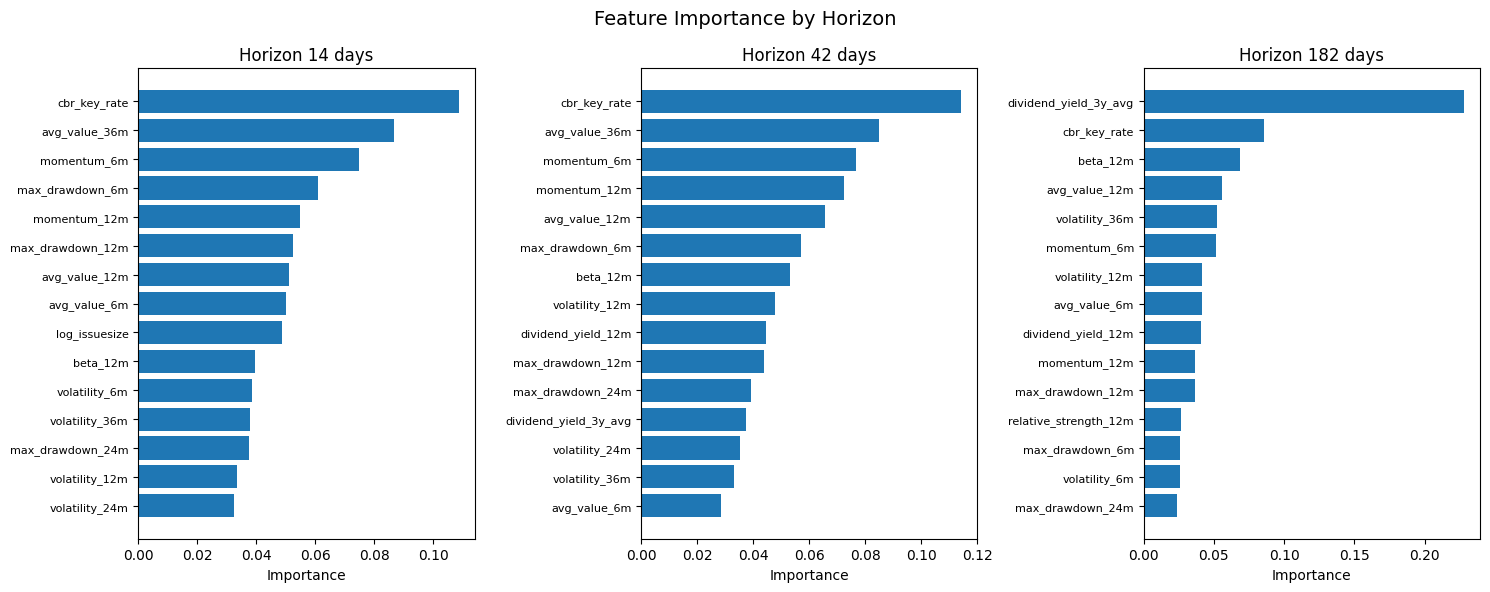

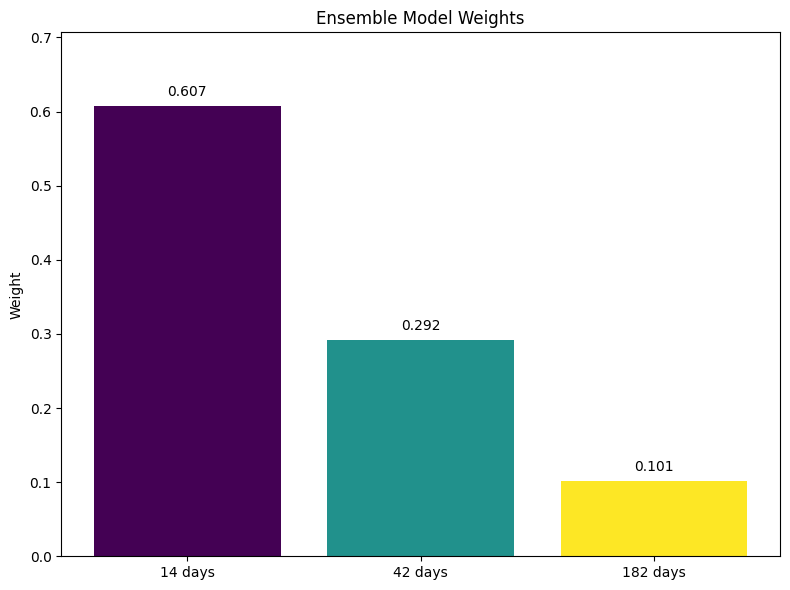


MODEL INFORMATION
Horizons: [14, 42, 182]

Last errors for each horizon:
  Horizon 14: 0.067045
  Horizon 42: 0.271673
  Horizon 182: 0.573429

Ensemble weights:
  Horizon 14: 0.6068
  Horizon 42: 0.2919
  Horizon 182: 0.1013


In [ ]:
import pickle
import joblib
import matplotlib.pyplot as plt
import numpy as np

def load_model_and_visualize(model_path="ensemble_180.pkl", feature_cols=None):
    print(f"Loading model from {model_path}...")
    orchestrator = joblib.load(model_path)
    print("Model loaded successfully!")
    
    if feature_cols is None:
        feature_cols = [
            "momentum_6m", "momentum_12m", "momentum_24m", "momentum_36m",
            "volatility_6m", "volatility_12m", "volatility_24m", "volatility_36m",
            "max_drawdown_6m", "max_drawdown_12m", "max_drawdown_24m", "max_drawdown_36m",
            "avg_value_6m", "avg_value_12m", "avg_value_36m",
            "dividend_yield_12m", "dividend_yield_3y_avg", "dividend_consistency_3y",
            "relative_strength_12m", "excess_return_6m", "beta_12m",
            "log_issuesize", "cbr_key_rate"
        ]
    
    visualize_model(orchestrator, feature_cols)
    
    return orchestrator

def visualize_model(orchestrator, feature_cols):
    n_models = len(orchestrator.horizons)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 6))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, horizon in enumerate(orchestrator.horizons):
        model = orchestrator.models[horizon].model
        importance = model.feature_importances_
        
        sorted_idx = np.argsort(importance)[::-1][:15]
        sorted_importance = importance[sorted_idx]
        sorted_features = [feature_cols[i] for i in sorted_idx]
        
        axes[idx].barh(range(len(sorted_idx)), sorted_importance[::-1])
        axes[idx].set_yticks(range(len(sorted_idx)))
        axes[idx].set_yticklabels(sorted_features[::-1], fontsize=8)
        axes[idx].set_xlabel('Importance')
        axes[idx].set_title(f'Horizon {horizon} days')
    
    plt.suptitle('Feature Importance by Horizon', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    weights = orchestrator._compute_weights()
    
    plt.figure(figsize=(8, 6))
    horizons_str = [f'{h} days' for h in orchestrator.horizons]
    colors = plt.cm.viridis(np.linspace(0, 1, len(horizons_str)))
    
    bars = plt.bar(horizons_str, weights.values(), color=colors)
    plt.ylabel('Weight')
    plt.title('Ensemble Model Weights')
    
    for bar, weight in zip(bars, weights.values()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{weight:.3f}', ha='center', va='bottom')
    
    plt.ylim(0, max(weights.values()) + 0.1)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*50)
    print("MODEL INFORMATION")
    print("="*50)
    print(f"Horizons: {orchestrator.horizons}")
    print(f"\nLast errors for each horizon:")
    for h in orchestrator.horizons:
        if orchestrator.errors[h]:
            print(f"  Horizon {h}: {orchestrator.errors[h][-1]:.6f}")
    
    print(f"\nEnsemble weights:")
    for h, w in weights.items():
        print(f"  Horizon {h}: {w:.4f}")

if __name__ == "__main__":
    orchestrator = load_model_and_visualize("ensemble_180_1.pkl")